**Tunneling Barrier Fitting**

Data loaded successfully:7
Starting fitting process...
Iteration 5, Residual: 115.047883, Best Residual: 50.919737
Iteration 10, Residual: 59.352566, Best Residual: 1.740000
Iteration 15, Residual: 14.788605, Best Residual: 1.740000
Iteration 20, Residual: 115.592104, Best Residual: 1.740000
Iteration 20, Residual: 59.396337, Best Residual: 1.740000


c:\Users\10925\miniconda3\Lib\site-packages\uncertainties\core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


Fitted parameters by differential evolution:
phi_p: 2.085
m_p: 1.33
phi_n: 1.8425465497739915
m_n: 1.33
continual fitting by least square method:
Iteration 5, Residual: 1.723908, Best Residual: 1.723908
Iteration 5, Residual: 1.723908, Best Residual: 1.723908
Fitted parameters by least squares:
phi_p: 2.085
m_p: 1.33
phi_n: 1.5102343504656286
m_n: 1.33
Best parameters (with smallest residual):
phi_p: 2.085
m_p: 1.33
phi_n: 1.5102343504656286
m_n: 1.33
Peak Electric Field: -9.44e+08 V/m


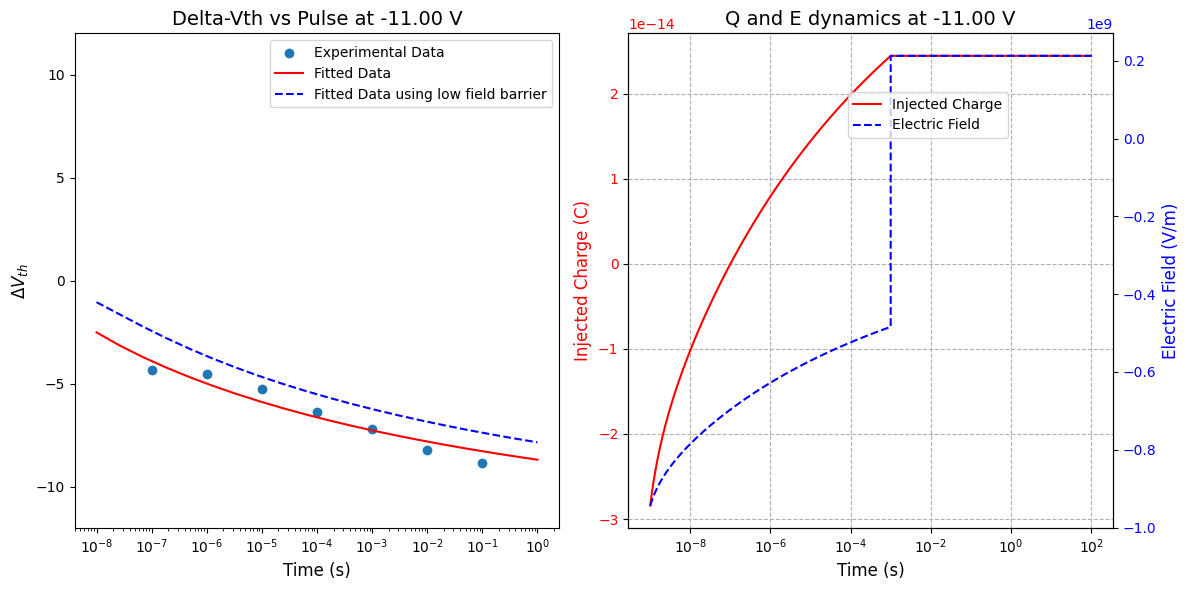

In [ ]:
from multiprocessing import Pool, cpu_count
from FGT_model_ver0 import _process_single_point
from FGT_model_ver0 import FloatingGateTransistor
from lmfit import Model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math


GCR = 0.646 # Gate coupling ratio
Vth_fg = 0 # Set the floating-gate threshold voltage
t_ox = 10.2e-9 # Oxide thickness
points_per_group = 8 # Each group contains 8 data points

i = 6 # Select the i-th group of data (8 points per group) +/- 5,6,7,8,9,10,11,12,13,14
      # 0,1,2.......
pos = False # True for positive bias, False for negative bias; check whether the imported file voltage polarity is correct
phi_n0 = 1.645 # Initial tunneling barrier under negative bias, corresponding to the charge-retention stage
phi_p0 = 2.085 # Initial tunneling barrier under positive bias, corresponding to the charge-retention stage

# Multi-processing function
def fgt(V_prog, t_prog, Vth_ref, phi_p, m_p, phi_n, m_n, Vth_fg=Vth_fg, t_ox=t_ox, GCR=GCR):
    args_list = [(V_prog[i], t_prog[i], Vth_ref[i], phi_p, m_p, phi_n, m_n, Vth_fg, t_ox, GCR) for i in range(len(V_prog))]
    with Pool(processes=cpu_count()) as pool:
        vth = pool.map(_process_single_point, args_list)
    return np.array(vth)


def iter_callback(params, iter, resid, *args, **kwargs):
    
    global best_params, best_residual
    current_residual = np.sum(resid**2)
    if current_residual < best_residual:
        best_residual = current_residual
        best_params = params.copy()  # Save the current best parameters
    if iter > 0 and iter % 5 == 0:
        print(f"Iteration {iter}, Residual: {current_residual:.6f}, Best Residual: {best_residual:.6f}")

if __name__ == '__main__':
        
    file_path = '2025.11.11-4-8580 neg.xlsx'  # Check the file path
    df_raw = pd.read_excel(file_path)
    
    
    # Select the i-th group of data (8 points per group)
    # i = 1  # Select the second group
    df = df_raw.iloc[i*points_per_group+1 : (i+1)*points_per_group] # Remove the first 10 ns point
    
    # Load experimental data
    t_pulse = df['t_pulse'].values
    Vprog_erase = df['Vprog_erase'].values
    Vth_delta = df['Vth_delta'].values
    Vth_ref = df['Vth_ref'].values
    print(f'Data loaded successfully:{len(Vth_delta)}')
    
    # Choose values for fitting
    
    

    best_params = None
    best_residual = np.inf

    print("Starting fitting process...")
    model = Model(fgt, independent_vars=['V_prog', 't_prog', 'Vth_ref'], 
                  param_names=['phi_p', 'm_p', 'phi_n', 'm_n'])
    params = model.make_params()
    params['m_n'].set(value=1.33, vary=False) # Hole mass for hBN
    params['m_p'].set(value=1.33, vary=False) # Hole mass for hBN
    
    if pos:
        params['phi_p'].set(value=1.95, min=1.0, max=2.2, vary=True)
        params['phi_n'].set(value=phi_n0, vary=False)
    else:
        params['phi_p'].set(value=phi_p0, vary=False)
        params['phi_n'].set(value=1.35, min=0.75, max=2.0, vary=True)

    result = model.fit(Vth_delta, params, 
                V_prog=Vprog_erase, t_prog=t_pulse, Vth_ref=Vth_ref, 
                max_nfev=20,
                method='differential_evolution', 
                iter_cb=iter_callback)
        # Output fitted parameters
        
    print("Fitted parameters by differential evolution:")
    for param_name, param in result.params.items():
        print(f"{param_name}: {param.value}")

    print("continual fitting by least square method:")
    # Continue fitting using the optimal parameters
    result = model.fit(Vth_delta, best_params, 
                    V_prog=Vprog_erase, t_prog=t_pulse, Vth_ref=Vth_ref, 
                    max_nfev=20, 
                    iter_cb=iter_callback)

    # Output fitted parameters
    print("Fitted parameters by least squares:")
    for param_name, param in result.params.items():
        print(f"{param_name}: {param.value}")

    print("Best parameters (with smallest residual):")
    for name, param in best_params.items():
        print(f"{name}: {param.value}")


    t_pulse_fit = np.logspace(-8, 0, 20)    
    Vprog_erase_fit = np.ones_like(t_pulse_fit) * Vprog_erase[0]  # Assuming V_prog is constant for fitting
    Vth_ref_fit = np.ones_like(t_pulse_fit) * Vth_ref[0]
    # Predict using the fitted model
    fitted_vth = model.eval(params=best_params, V_prog=Vprog_erase_fit, t_prog=t_pulse_fit, Vth_ref=Vth_ref_fit)


    m_n = best_params['m_n'].value
    m_p = best_params['m_p'].value
    phi_n = best_params['phi_n'].value
    phi_p = best_params['phi_p'].value
    Vth0 = Vth_ref[0]
    Vprog_erase = Vprog_erase[0]
    
    
    # best_params['phi_n'].value = phi_n0
    params_0 = best_params.copy()
    if pos:
        params_0['phi_p'].value = phi_p0
    else:
        params_0['phi_n'].value = phi_n0
    fitted_vth_0 = model.eval(params=params_0, V_prog=Vprog_erase_fit, t_prog=t_pulse_fit, Vth_ref=Vth_ref_fit)



        
    # Create two side-by-side subplots
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    # First subplot: experimental data + fitted data
    j = 0
    ax0 = ax[0]
    ax0.scatter(t_pulse[8*j:8*(j+1)], Vth_delta[8*j:8*(j+1)], label='Experimental Data')
    ax0.plot(t_pulse_fit, fitted_vth, '-', label='Fitted Data', color='red')
    ax0.plot(t_pulse_fit, fitted_vth_0, '--', label='Fitted Data using low field barrier', color='blue')
    ax0.set_xscale('log')
    ax0.set_ylim(-12, 12)
    ax0.set_xlabel('Time (s)', fontsize=12)
    ax0.set_ylabel(r'$\Delta V_{th}$', fontsize=12)
    ax0.set_title(f'Delta-Vth vs Pulse at {Vprog_erase:.2f} V', fontsize=14)
    ax0.legend(loc='best')

     # Second subplot: t-Q and t-E curves
    x = FloatingGateTransistor(t_ox=t_ox, GCR=GCR, Vth_fg=Vth_fg, m_n=m_n, m_p=m_p, phi_n=phi_n, phi_p=phi_p)
    _, t_all, Q_all, E_all = x.ProgErase_pulse(1e-3, Vprog_erase, Vth_0=Vth0, Vth_fg=Vth_fg, plot=False)
    E_peak = max(E_all, key=abs)
    print(f"Peak Electric Field: {E_peak:.2e} V/m")


    # Primary y-axis: injected charge Q
    ax1 = ax[1]
    line1, = ax1.plot(t_all, Q_all, 'r-', label='Injected Charge')
    ax1.set_xscale('log')
    ax1.set_xlabel('Time (s)', fontsize=12)
    ax1.set_ylabel('Injected Charge (C)', color='r', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='r')
    ax1.grid(True, which='both', linestyle='--')
    ax1.set_title(f'Q and E dynamics at {Vprog_erase:.2f} V', fontsize=14)

    # Secondary y-axis: electric field E
    ax2 = ax1.twinx()
    line2, = ax2.plot(t_all, E_all, 'b--', label='Electric Field')
    ax2.set_ylabel('Electric Field (V/m)', color='b', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='b')

    # Unified legend
    fig.legend([line1, line2], ['Injected Charge', 'Electric Field'], loc='upper right', bbox_to_anchor=(0.85, 0.85))

    # Optimize layout
    plt.tight_layout()
    plt.show()


**Evolution of FGT Q/E Under a Pulse**

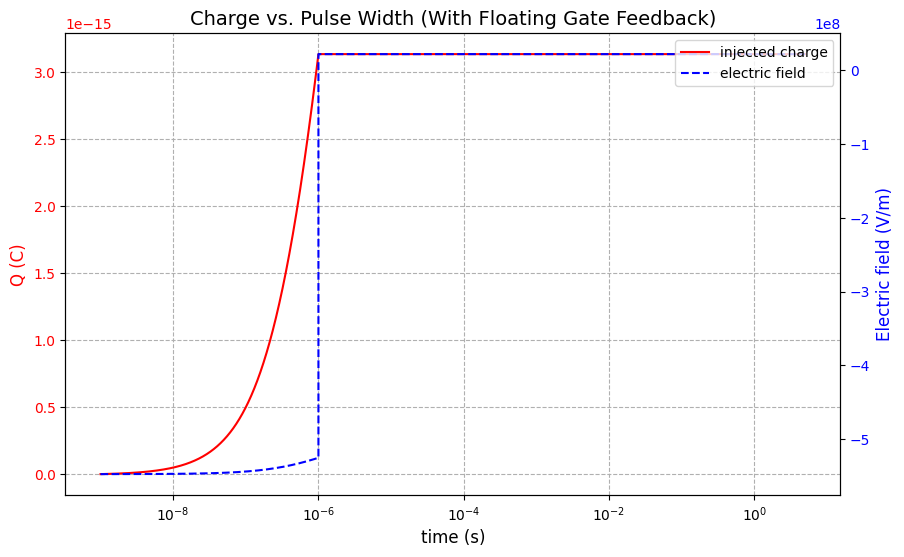

(-0.48568789585191735,
 [1e-09,
  1.01e-09,
  1.02e-09,
  1.03e-09,
  1.04e-09,
  1.0499999999999999e-09,
  1.0599999999999999e-09,
  1.0699999999999998e-09,
  1.0799999999999998e-09,
  1.0899999999999998e-09,
  1.0999999999999997e-09,
  1.1099999999999997e-09,
  1.1199999999999996e-09,
  1.1299999999999996e-09,
  1.1399999999999996e-09,
  1.1499999999999995e-09,
  1.1599999999999995e-09,
  1.1699999999999995e-09,
  1.1799999999999994e-09,
  1.1899999999999994e-09,
  1.1999999999999994e-09,
  1.2099999999999993e-09,
  1.2199999999999993e-09,
  1.2299999999999993e-09,
  1.2399999999999992e-09,
  1.2499999999999992e-09,
  1.2599999999999992e-09,
  1.2699999999999991e-09,
  1.279999999999999e-09,
  1.289999999999999e-09,
  1.299999999999999e-09,
  1.309999999999999e-09,
  1.319999999999999e-09,
  1.329999999999999e-09,
  1.3399999999999989e-09,
  1.3499999999999989e-09,
  1.3599999999999988e-09,
  1.3699999999999988e-09,
  1.3799999999999988e-09,
  1.3899999999999987e-09,
  1.399999999999

In [ ]:
from FGT_model_ver0 import FloatingGateTransistor
x = FloatingGateTransistor(t_ox = 16.0e-9, Vth_fg =0, GCR = 0.73, m_n=1.33, m_p =1.33, phi_n=1.35, phi_p=1.635)
x.read_time =5   
# Time window
x.ProgErase_pulse(1e-6, -12, Vth_0=0, Vth_fg=0, plot=True, RESET=True)
# Pulse width, pulse amplitude, initial threshold voltage, threshold offset induced by floating-gate charge, whether to plot, whether to reset

**Single-Step Programming to a Target Vth**

In [9]:
from FGT_model_ver0 import FloatingGateTransistor
import numpy as np

def find_voltage_for_Vth(target_Vth, t_pulse=1e-6, Vth_0=4,
                         start_voltage=0, end_voltage=-10, step=-0.1,
                         tolerance=0.02):
    """
    Parameters:
    target_Vth: target threshold voltage (V)
    t_pulse: pulse width (s)
    Vth_0: initial threshold voltage (V) — written into the model each time RESET=True
    start_voltage: starting search voltage (V)
    end_voltage: ending search voltage (V)
    step: voltage step size (V)
    tolerance: acceptable error range for threshold voltage (V)

    Returns:
    The identified voltage and the corresponding final threshold voltage.
    If no exact match is found, the closest result is returned.
    """
    # Create the device instance
    fgt = FloatingGateTransistor(
        t_ox=17.7e-9, Vth_fg=0, GCR=0.75,
        m_n=1.33, m_p=1.33, phi_n=1.309, phi_p=1.73
    )
    fgt.read_time = 5

    # Generate the voltage search list
    voltages = np.arange(start_voltage, end_voltage - step / 2, -step)

    best_voltage = None
    best_Vth = None
    min_diff = float('inf')

    print(f"Searching for target threshold voltage {target_Vth} V... (Vth_0={Vth_0} V, t_pulse={t_pulse}s)")

    for v in voltages:
        # Reset the device state before each test
        fgt.reset()

        # Apply a pulse with the current voltage (RESET=True)
        delta_Vth, _, _, _ = fgt.ProgErase_pulse(
            t_pulse, v, Vth_0=Vth_0, Vth_fg=0, plot=False, RESET=True
        )

        # Calculate the final threshold voltage
        final_Vth = Vth_0 + delta_Vth
        current_diff = abs(final_Vth - target_Vth)

        if abs(v - round(v)) < 1e-9:
            print(f"Voltage: {v:.1f} V, Final threshold voltage: {final_Vth:.4f} V, Difference from target: {current_diff:.4f} V")

        # Check whether the target is reached
        if current_diff < tolerance:
            print(f"Matching voltage found: {v:.1f} V, Corresponding final threshold voltage: {final_Vth:.4f} V (ΔVth = {delta_Vth:.4f} V)")
            return v, final_Vth

        # Update the best match
        if current_diff < min_diff:
            min_diff = current_diff
            best_voltage = v
            best_Vth = final_Vth

    # If no exact match is found, return the closest result
    print(f"No exact matching voltage found. Best match: {best_voltage:.1f} V, Corresponding final threshold voltage: {best_Vth:.4f} V, Difference: {min_diff:.4f} V")
    return best_voltage, best_Vth


# ===== Example usage =====
target_Vth = 3.375  # Desired final threshold voltage
v_found, vth_found = find_voltage_for_Vth(
    target_Vth, t_pulse=1e-6, Vth_0=4,
    start_voltage=0, end_voltage=-15,
    step=0.1, tolerance=0.02
)
print("Result:", v_found, vth_found)

Searching for target threshold voltage 3.375 V... (Vth_0=4 V, t_pulse=1e-06s)
Voltage: 0.0 V, Final threshold voltage: 4.0000 V, Difference from target: 0.6250 V
Voltage: -1.0 V, Final threshold voltage: 4.0000 V, Difference from target: 0.6250 V
Voltage: -2.0 V, Final threshold voltage: 4.0000 V, Difference from target: 0.6250 V
Voltage: -3.0 V, Final threshold voltage: 4.0000 V, Difference from target: 0.6250 V
Voltage: -4.0 V, Final threshold voltage: 4.0000 V, Difference from target: 0.6250 V
Voltage: -5.0 V, Final threshold voltage: 3.9999 V, Difference from target: 0.6249 V
Voltage: -6.0 V, Final threshold voltage: 3.9973 V, Difference from target: 0.6223 V
Voltage: -7.0 V, Final threshold voltage: 3.9607 V, Difference from target: 0.5857 V
Voltage: -8.0 V, Final threshold voltage: 3.7084 V, Difference from target: 0.3334 V
Voltage: -9.0 V, Final threshold voltage: 3.0268 V, Difference from target: 0.3482 V
Voltage: -10.0 V, Final threshold voltage: 2.1048 V, Difference from targ

**Model-Guided Optimization of VProgram and ΔVStep for FG Programming**

In [10]:
import numpy as np
import pandas as pd
from FGT_model_ver0 import FloatingGateTransistor

def pulse_sweep_reset_each_time_v3(
    V_base=-8.6,        # Base voltage
    V_steps=[-0.6],     # List of multiple step values (default: [-0.6])
    n_pulses=16,        # Number of pulses
    t_pulse=1e-6,       # Pulse width
    Vth_0=4.0,          # Reset to this initial threshold voltage every time
    Vth_fg=0.0,         # Floating-gate threshold calibration term
    verbose=True
):
    """
    Each pulse starts from the same initial state (reset + RESET=True),
    and the voltage increases stepwise according to V_base + k*V_step.
    Multiple V_step values are accepted and executed one by one.
    Returns ΔVth and Vth_final for each pulse.
    """

    # Store all final results
    all_results = []

    # 1) Create the device instance
    fgt = FloatingGateTransistor(
        t_ox=17.7e-9, Vth_fg=0, GCR=0.75,
        m_n=1.33, m_p=1.33, phi_n=1.309, phi_p=1.73
    )
    fgt.read_time = 5

    if verbose:
        print("V_step\tIndex\tV_pulse(V)\tDelta_Vth(V)\tVth_final(V)")

    # 2) Perform stepwise calculation for each V_step
    for V_step in V_steps:
        # Generate the pulse-voltage sequence: V_base, V_base+step, V_base+2*step, ...
        V_list = V_base + V_step * np.arange(n_pulses)

        deltaVth_list = np.zeros(n_pulses, dtype=float)
        Vth_final_list = np.zeros(n_pulses, dtype=float)

        # 3) Loop: reset to the same initial state each time, then apply one pulse and record the threshold-voltage change
        for k, V_pulse in enumerate(V_list):
            fgt.reset()
            delta_Vth, _, _, _ = fgt.ProgErase_pulse(
                t_pulse=t_pulse,
                V_pulse=float(V_pulse),
                Vth_0=Vth_0,
                Vth_fg=Vth_fg,
                plot=False,
                RESET=True
            )

            deltaVth_list[k] = float(delta_Vth)
            Vth_final_list[k] = Vth_0 + deltaVth_list[k]

            if verbose:
                print(f"{V_step}\t{k+1}\t{V_pulse:.3f}\t{deltaVth_list[k]:.5f}\t{Vth_final_list[k]:.5f}")

        # Save the results for the current V_step
        result = pd.DataFrame({
            "V_step": [V_step] * n_pulses,
            "Index": np.arange(1, n_pulses+1),
            "V_pulse(V)": V_list,
            "Delta_Vth(V)": deltaVth_list,
            "Vth_final(V)": Vth_final_list
        })
        all_results.append(result)

    # Merge all results into one DataFrame
    final_data = pd.concat(all_results, ignore_index=True)

    # Export to Excel
    final_data.to_excel("Voltage_Threshold_Sweep.xlsx", index=False)

    return final_data


# ===== Example =====
if __name__ == "__main__":
    V_steps = [-0.1, -0.2, -0.3, -0.4, -0.5, -0.6, -0.7, -0.8, -0.9, -1, -1.1, -1.2, -1.3, -1.4, -1.5]  # Multiple V_step values to be tested
    result_data = pulse_sweep_reset_each_time_v3(
        V_base=-9.6,
        V_steps=V_steps,
        n_pulses=16,
        t_pulse=1e-6,
        Vth_0=4.0,
        Vth_fg=0.0,
        verbose=True
    )

    print("\nResult DataFrame:")
    print(result_data)

V_step	Index	V_pulse(V)	Delta_Vth(V)	Vth_final(V)
-0.1	1	-9.600	-1.51344	2.48656
-0.1	2	-9.700	-1.60778	2.39222
-0.1	3	-9.800	-1.70293	2.29707
-0.1	4	-9.900	-1.79875	2.20125
-0.1	5	-10.000	-1.89516	2.10484
-0.1	6	-10.100	-1.99207	2.00793
-0.1	7	-10.200	-2.08941	1.91059
-0.1	8	-10.300	-2.18710	1.81290
-0.1	9	-10.400	-2.28511	1.71489
-0.1	10	-10.500	-2.38339	1.61661
-0.1	11	-10.600	-2.48190	1.51810
-0.1	12	-10.700	-2.58060	1.41940
-0.1	13	-10.800	-2.67947	1.32053
-0.1	14	-10.900	-2.77849	1.22151
-0.1	15	-11.000	-2.87764	1.12236
-0.1	16	-11.100	-2.97689	1.02311
-0.2	1	-9.600	-1.51344	2.48656
-0.2	2	-9.800	-1.70293	2.29707
-0.2	3	-10.000	-1.89516	2.10484
-0.2	4	-10.200	-2.08941	1.91059
-0.2	5	-10.400	-2.28511	1.71489
-0.2	6	-10.600	-2.48190	1.51810
-0.2	7	-10.800	-2.67947	1.32053
-0.2	8	-11.000	-2.87764	1.12236
-0.2	9	-11.200	-3.07624	0.92376
-0.2	10	-11.400	-3.27516	0.72484
-0.2	11	-11.600	-3.47433	0.52567
-0.2	12	-11.800	-3.67369	0.32631
-0.2	13	-12.000	-3.87318	0.12682
-0.2	14	-12.200	-